# Notebook 06.1 — Testes das Hipóteses (H1 socioterritorial e H2 metodológica)

**Projeto:** Acessibilidade Geográfica às UBS de Teresina — roteiro computacional AE2SFCA  
**Programa:** MAPEPROF — Mestrado Profissional em Planejamento Urbano e Regional / IFPI  
**Autor:** Felipe Ramos Dantas  
**Orientador:** Prof. Dr. Antonio Joaquim da Silva  
**Coorientador:** Prof. Dr. Reurysson Chagas de Sousa Morais  
**Repositório:** https://github.com/felipedantas-pi/ae2sfca-ubs  
**Apêndice:** I · **Última atualização:** 2026-06-23 

---
## Objetivo
Testar as hipóteses: **H2** (o diagnóstico areal difere do E2SFCA tradicional) e **H1** (a
acessibilidade associa-se à renda, com exclusão na periferia). Métodos: correlação de
Spearman, reclassificação de "desertos" e autocorrelação espacial (Moran/LISA).

## Entrada
| Arquivo | Origem |
|---|---|
| `processados/teresina_setores_acessibilidade.parquet` | NB 05 |
| `intermediarios/01_malha/teresina_setoresCensitarios_DadosCompletos.parquet` (renda V06004) | NB 01.1 |
---

## 1. Configuração e importações

Bibliotecas (incl. `esda`/`libpysal` para Moran/LISA), *helpers* do projeto e criação das subpastas de saída (`nb061`).

In [1]:
# ── 1. IMPORTAÇÕES ──────────────────────────────────────────────────────────
import warnings

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from esda.moran import Moran, Moran_BV, Moran_Local_BV
from libpysal.weights import KNN
from matplotlib.patches import Patch
from scipy.stats import spearmanr, pearsonr

from mapeprof.config import (
    CRS_METRICO,
    EXT_IBGE,
    FIGURAS,
    INT_MALHA,
    PROCESSADOS,
    TABELAS,
    criar_diretorios,
)
from mapeprof.viz import (
    ajustar_zoom_camada,
    aplicar_estilo,
    barra_escala,
    formatar_eixos_mapa,
    moldura_mapa,
    seta_norte,
)

aplicar_estilo()
warnings.filterwarnings("ignore")
criar_diretorios()
FIGURAS_NB = FIGURAS / "nb061"; FIGURAS_NB.mkdir(parents=True, exist_ok=True)
TABELAS_NB = TABELAS / "nb061"; TABELAS_NB.mkdir(parents=True, exist_ok=True)

FONTE_PADRAO = "CNES/DataSUS; IBGE (2022); Overture Maps Foundation (2026). Elaboração própria."
print("✅ Setup concluído.")

✅ Setup concluído.


## 2. Carga dos dados

Carga da acessibilidade por setor (NB 05.1) e da renda **mediana** do responsável (NB 01.1); merge por `CD_SETOR`.

In [2]:
# ── 2. CARGA: ACESSIBILIDADE (NB 05) + RENDA MEDIANA (NB 01.1) ───────────────
gdf_zu = gpd.read_parquet(EXT_IBGE / "teresina_zonaUrbana_utm.parquet").to_crs(CRS_METRICO)
ac = gpd.read_parquet(PROCESSADOS / "teresina_setores_acessibilidade.parquet").to_crs(CRS_METRICO)

# H2 usa a renda MEDIANA (resistente à assimetria — ver metodologia 4.x)
renda = (gpd.read_parquet(INT_MALHA / "teresina_setoresCensitarios_DadosCompletos.parquet")
         [["CD_SETOR", "renda_mediana"]])
renda["renda_mediana"] = pd.to_numeric(renda["renda_mediana"], errors="coerce")
ac = ac.merge(renda, on="CD_SETOR", how="left")
print(f"🔄 {len(ac)} setores | com renda mediana: {ac['renda_mediana'].notna().sum()}")

🔄 1375 setores | com renda mediana: 1340


## 3. Teste de H2 — abordagem areal vs. tradicional (centroide)

Compara-se o índice AE2SFCA areal (`acess_carro`) ao E2SFCA por centroide
(`acess_carro_e2sfca`), sob idêntica parametrização. A divergência é medida pela correlação
de postos e pela contagem de setores que mudam de classificação "deserto de saúde".

In [3]:
# ── 3. H2 — areal (AE2SFCA) × centroide (E2SFCA), nos dois modos ─────────────
h2 = {}
for modo in ["carro", "pe"]:
    col_a, col_c = f"acess_{modo}", f"acess_{modo}_e2sfca"
    val = ac[(ac[col_a] > 0) & (ac[col_c] > 0)]
    rho, p = spearmanr(val[col_a], val[col_c])
    ac[f"reclass_{modo}"] = ac[f"deserto_{modo}"] != ac[f"deserto_{modo}_e2sfca"]
    so_a = int(( ac[f"deserto_{modo}"] & ~ac[f"deserto_{modo}_e2sfca"]).sum())
    so_c = int((~ac[f"deserto_{modo}"] &  ac[f"deserto_{modo}_e2sfca"]).sum())
    h2[modo] = {"spearman": round(rho, 3), "p_valor": f"{p:.1e}",
                "desertos_areal": int(ac[f"deserto_{modo}"].sum()),
                "desertos_centroide": int(ac[f"deserto_{modo}_e2sfca"].sum()),
                "reclassificados": int(ac[f"reclass_{modo}"].sum()),
                "reclass_pct": round(ac[f"reclass_{modo}"].mean()*100, 1),
                "so_areal": so_a, "so_centroide": so_c}
    print(f"H2 ({modo}): Spearman={rho:.3f} (p={p:.1e}) | desertos areal={h2[modo]['desertos_areal']} "
          f"centroide={h2[modo]['desertos_centroide']} | reclass={h2[modo]['reclassificados']} "
          f"({h2[modo]['reclass_pct']}%) [só areal={so_a}, só centroide={so_c}]")

pd.DataFrame(h2).T.to_csv(TABELAS_NB / "nb061_h2_sintese.csv", sep=";", encoding="utf-8-sig")

H2 (carro): Spearman=0.991 (p=0.0e+00) | desertos areal=344 centroide=345 | reclass=23 (1.7%) [só areal=11, só centroide=12]
H2 (pe): Spearman=0.949 (p=0.0e+00) | desertos areal=358 centroide=408 | reclass=78 (5.7%) [só areal=14, só centroide=64]


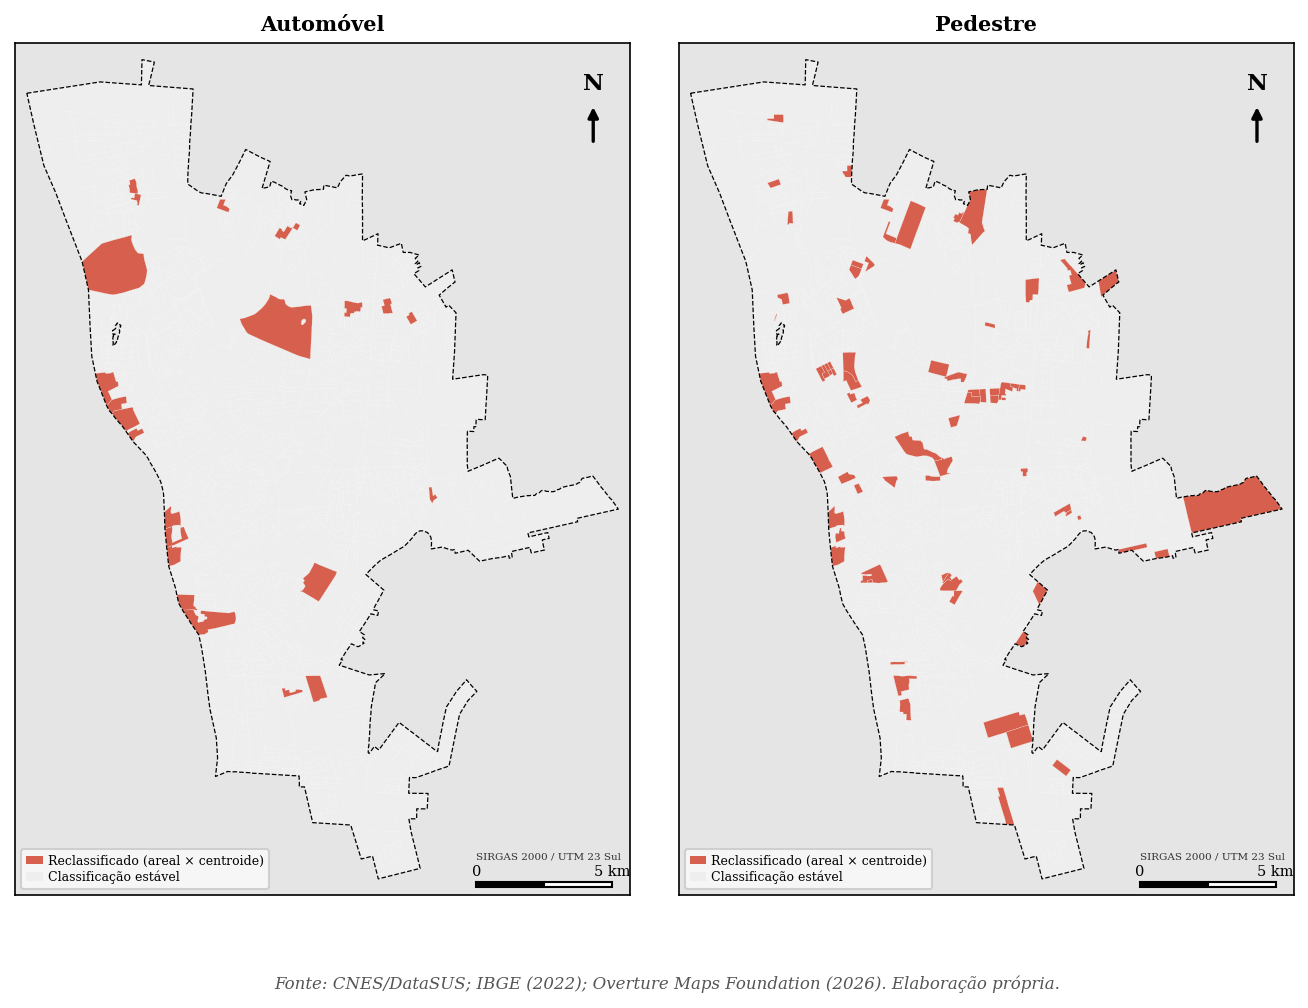

In [4]:
# ── Fig. 01 — Setores reclassificados (H2), automóvel e pedestre ────────────
FONTE_LEGENDA = 6
FONTE_CRS = 5

def painel_reclass(ax, modo, titulo):
    ax.set_facecolor("#E5E5E5")
    ac.plot(ax=ax, color="#EEEEEE", edgecolor="white", linewidth=0.1, zorder=2)
    ac[ac[f"reclass_{modo}"]].plot(ax=ax, color="#D6604D", edgecolor="white", linewidth=0.1, zorder=3)
    gdf_zu.boundary.plot(ax=ax, color="black", ls="--", lw=0.6, zorder=4)
    ajustar_zoom_camada(ax, gdf_zu, margem=0.02)
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(titulo, fontsize=10, fontweight="bold")

    ax.legend(handles=[Patch(facecolor="#D6604D", label="Reclassificado (areal × centroide)"),
                       Patch(facecolor="#EEEEEE", label="Classificação estável")],
              loc="lower left", fontsize=FONTE_LEGENDA, framealpha=0.9)

    barra_escala(ax, frac_x=0.75)
    seta_norte(ax)

    x0, x1 = ax.get_xlim(); y0, y1 = ax.get_ylim()
    ax.text(x0 + (x1 - x0) * 0.75, y0 + (y1 - y0) * 0.04,
            "SIRGAS 2000 / UTM 23 Sul", ha="left", va="bottom",
            fontsize=FONTE_CRS, color="#333333", zorder=10)

fig, axes = plt.subplots(1, 2, figsize=(9, 7))
painel_reclass(axes[0], "carro", "Automóvel")
painel_reclass(axes[1], "pe",    "Pedestre")
fig.text(0.5, 0.02, f"Fonte: {FONTE_PADRAO}", ha="center", fontsize=8, style="italic", color="#555")

fig.tight_layout(rect=[0, 0.03, 1, 1])
fig.savefig(FIGURAS_NB / "nb061_fig01_h2_divergencias.png", dpi=300, bbox_inches="tight")
plt.show()

## 4. Teste de H1 — acessibilidade e renda

Avalia-se a associação entre o índice de acessibilidade e a renda mediana do responsável,
pela correlação de Spearman (associação global) e pela autocorrelação espacial bivariada
de Moran e seus indicadores locais (LISA), identificando agrupamentos significativos de
baixa acessibilidade e baixa renda (*low-low*).

In [5]:
# ── 4. H2 — acesso (automóvel) × renda mediana ──────────────────────────────
sub = ac[ac["renda_mediana"].notna() & (ac["acess_carro"] > 0)].reset_index(drop=True)
rho_h1, p_h1 = spearmanr(sub["acess_carro"], sub["renda_mediana"])

w = KNN.from_dataframe(sub, k=8); w.transform = "r"   # KNN evita "ilhas" do Queen
moran_acesso = Moran(sub["acess_carro"].values, w)
moran_bv = Moran_BV(sub["acess_carro"].values, sub["renda_mediana"].values, w)
lisa = Moran_Local_BV(sub["acess_carro"].values, sub["renda_mediana"].values, w, seed=42)

ROTULO = {1: "Alto acesso–Alta renda", 2: "Baixo acesso–Alta renda",
          3: "Baixo acesso–Baixa renda", 4: "Alto acesso–Baixa renda"}
sub["q"]   = lisa.q
sub["sig"] = lisa.p_sim < 0.05
sub["cluster"] = np.where(sub["sig"], pd.Series(lisa.q).map(ROTULO), "Não significativo")

print(f"H1 | Spearman acesso × renda_mediana = {rho_h1:+.3f} (p={p_h1:.1e})")
print(f"   Moran I global = {moran_acesso.I:.3f} (p={moran_acesso.p_sim:.3f}) | "
      f"bivariado = {moran_bv.I:+.3f} (p={moran_bv.p_sim:.3f})")
print(sub.loc[sub['sig'], "cluster"].value_counts().to_string())

H1 | Spearman acesso × renda_mediana = +0.438 (p=5.5e-64)
   Moran I global = 0.933 (p=0.001) | bivariado = +0.312 (p=0.001)
cluster
Baixo acesso–Baixa renda    307
Alto acesso–Baixa renda     144
Alto acesso–Alta renda      125
Baixo acesso–Alta renda       5


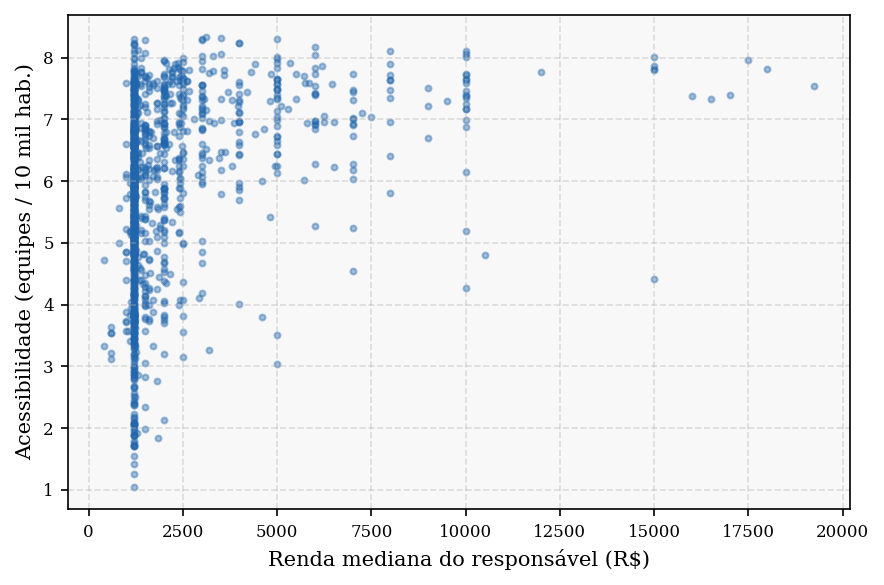

In [6]:
# ── Fig. 02 — Dispersão acesso × renda mediana ──────────────────────────────
fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(sub["renda_mediana"], sub["acess_carro"] * 1e4, s=8, alpha=0.4, color="#2166AC")
ax.set_xlabel("Renda mediana do responsável (R$)")
ax.set_ylabel("Acessibilidade (equipes / 10 mil hab.)")
plt.tight_layout()
fig.savefig(FIGURAS_NB / "nb061_fig02_h1_dispersao.png", dpi=300, bbox_inches="tight")
plt.show()

In [7]:
# ── Helper de mapa LISA (padrão cartográfico do projeto) ────────────────────
CLUSTERS = {1: ("Alto acesso / Alta renda",  "#D7191C"),
            3: ("Baixo acesso / Baixa renda", "#2C7BB6"),
            2: ("Baixo acesso / Alta renda",  "#FDAE61"),
            4: ("Alto acesso / Baixa renda",  "#ABD9E9")}

def mapa_lisa(gdf_clusters, arquivo, titulo_legenda):
    FONTE_CRS = 5
    fig, ax = plt.subplots(figsize=(5.8, 8.3)); ax.set_facecolor("#E5E5E5")
    ac.plot(ax=ax, color="#EEEEEE", edgecolor="white", linewidth=0.1, zorder=2)   # base
    handles = []
    for q, (rotulo, cor) in CLUSTERS.items():
        g = gdf_clusters[gdf_clusters["sig"] & (gdf_clusters["q"] == q)]
        if len(g):
            g.plot(ax=ax, color=cor, edgecolor="white", linewidth=0.1, zorder=3)
            handles.append(Patch(facecolor=cor, label=rotulo))
    handles.append(Patch(facecolor="#EEEEEE", label="Não significativo / sem dado"))
    gdf_zu.boundary.plot(ax=ax, color="black", ls="--", lw=0.6, zorder=4)
    ax.legend(handles=handles, title=titulo_legenda, loc="lower left",
              fontsize=6.5, title_fontsize=7.5, framealpha=0.9)
    ajustar_zoom_camada(ax, gdf_zu, margem=0.02)
    moldura_mapa(ax, "", FONTE_PADRAO)
    formatar_eixos_mapa(ax, fontsize=5)

    barra_escala(ax, frac_x=0.75); seta_norte(ax)

    x0, x1 = ax.get_xlim(); y0, y1 = ax.get_ylim()
    ax.text(x0 + (x1 - x0) * 0.75, y0 + (y1 - y0) * 0.04,
            "SIRGAS 2000 / UTM 23 Sul", ha="left", va="bottom",
            fontsize=FONTE_CRS, color="#333333", zorder=10)

    fig.savefig(FIGURAS_NB / arquivo, dpi=300, bbox_inches="tight")
    plt.show()

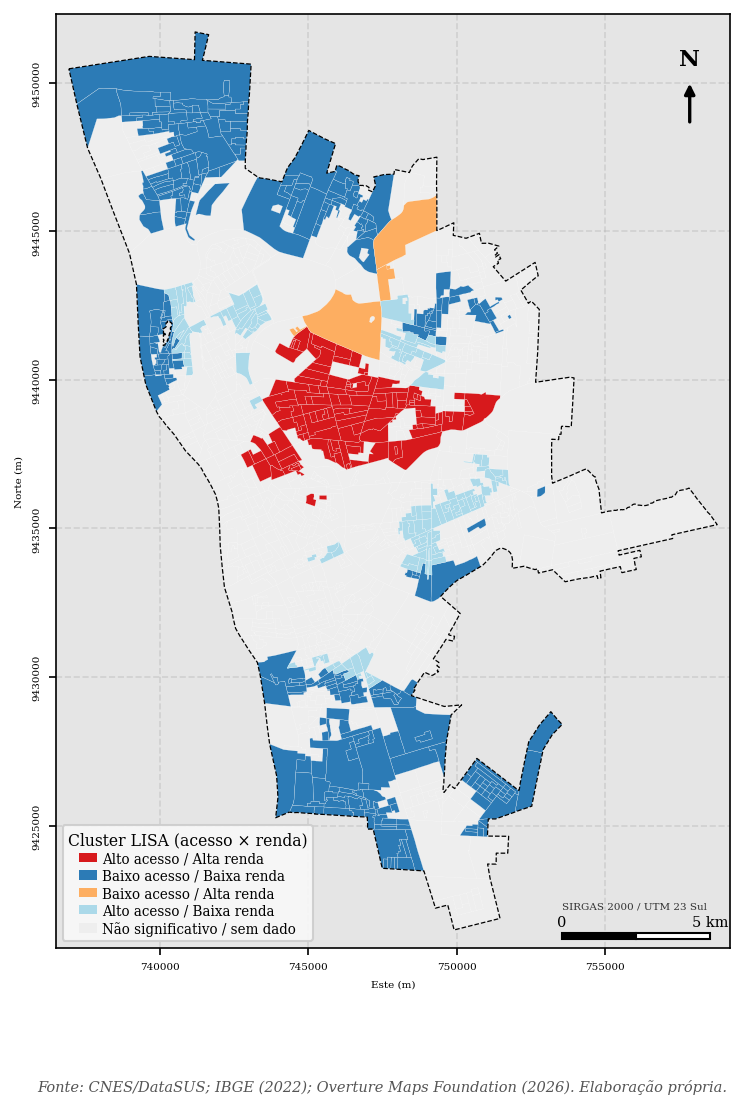

In [8]:
# ── Fig. 03 — Agrupamentos LISA (acesso automóvel × renda) ──────────────────
mapa_lisa(sub, "nb061_fig03_h1_lisa.png", "Cluster LISA (acesso × renda)")

## 5. Modo pedestre e comparação entre modos

Repete-se o teste de H2 para o índice de acessibilidade a pé (`acess_pe`) e confrontam-se
os dois modos. A análise revela em que medida o diagnóstico de equidade depende do meio de
transporte considerado.

In [ ]:
# ── 6. H1 — MODO PEDESTRE ───────────────────────────────────────────────────
subp = ac[ac["renda_mediana"].notna() & (ac["acess_pe"] > 0)].reset_index(drop=True)
rho_pe, p_pe = spearmanr(subp["acess_pe"], subp["renda_mediana"])
wp = KNN.from_dataframe(subp, k=8); wp.transform = "r"
moran_pe   = Moran(subp["acess_pe"].values, wp)
moranbv_pe = Moran_BV(subp["acess_pe"].values, subp["renda_mediana"].values, wp)
lisa_pe    = Moran_Local_BV(subp["acess_pe"].values, subp["renda_mediana"].values, wp, seed=42)

subp["q"]   = lisa_pe.q
subp["sig"] = lisa_pe.p_sim < 0.05
subp["cluster"] = np.where(subp["sig"], pd.Series(lisa_pe.q).map(ROTULO), "Não significativo")

n_sem_pe = int((ac["acess_pe"] == 0).sum())
print(f"H1 (pé) | Spearman acesso_pé×renda_mediana = {rho_pe:+.3f} (p={p_pe:.1e})")
print(f"   Moran I (pé) = {moran_pe.I:.3f} | bivariado = {moranbv_pe.I:+.3f} (p={moranbv_pe.p_sim:.3f})")
print(f"   desertos absolutos a pé (sem acesso) = {n_sem_pe} ({n_sem_pe/len(ac)*100:.1f}%)")
print(subp.loc[subp['sig'], "cluster"].value_counts().to_string())

# tabela-síntese da H1 (carro + pé)
pd.DataFrame({
    "automovel": {"spearman_acesso_renda": round(rho_h1,3), "moran_I": round(moran_acesso.I,3),
                  "moran_bv": round(moran_bv.I,3)},
    "pedestre":  {"spearman_acesso_renda": round(rho_pe,3), "moran_I": round(moran_pe.I,3),
                  "moran_bv": round(moranbv_pe.I,3)},
}).T.to_csv(TABELAS_NB / "nb061_h1_sintese.csv", sep=";", encoding="utf-8-sig")

H1 (pé) | Spearman acesso_pé×renda_mediana = -0.199 (p=2.5e-13)
   Moran I (pé) = 0.190 | bivariado = -0.148 (p=0.001)
   desertos absolutos a pé (sem acesso) = 18 (1.3%)
cluster
Alto acesso–Baixa renda     282
Baixo acesso–Baixa renda    174
Baixo acesso–Alta renda     123
Alto acesso–Alta renda        8


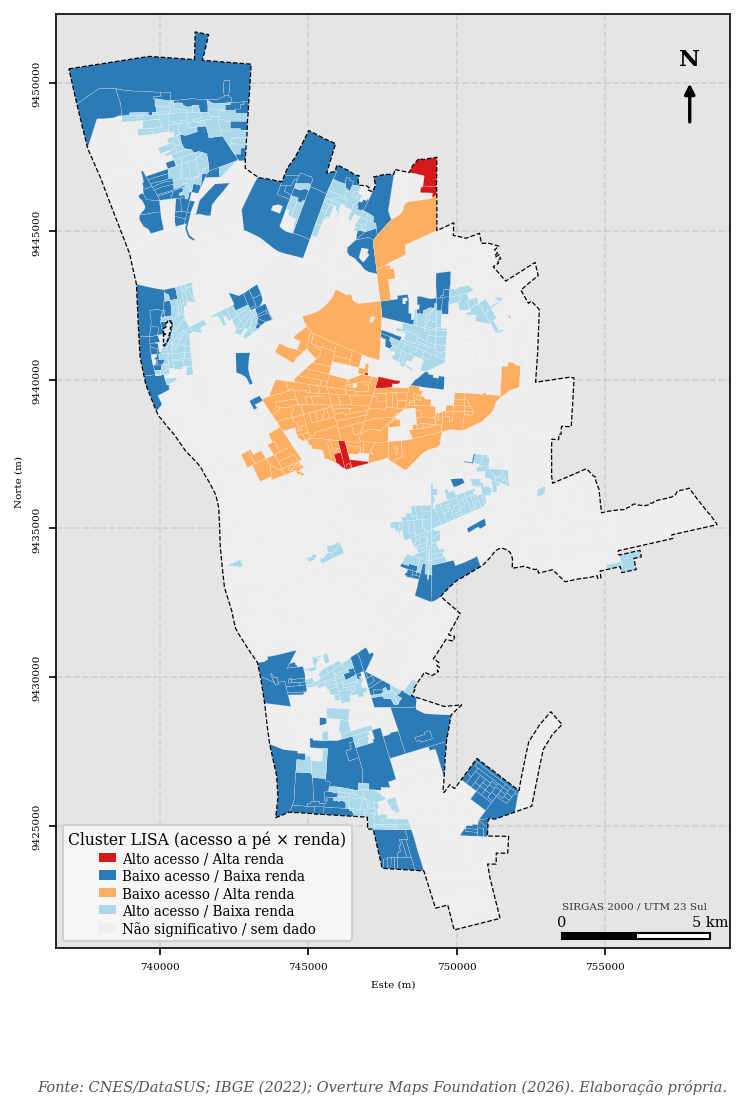

In [10]:
# ── Fig. 04 — Agrupamentos LISA (acesso a pé × renda) ───────────────────────
mapa_lisa(subp, "nb061_fig04_h1_lisa_pe.png", "Cluster LISA (acesso a pé × renda)")

In [11]:
# ── Tabela — distribuição dos setores por quadrante LISA, por modo ───────────
ORD = {1: "Alto acesso–Alta renda (HH)",   2: "Baixo acesso–Alta renda (LH)",
       3: "Baixo acesso–Baixa renda (LL)",  4: "Alto acesso–Baixa renda (HL)"}

def conta_clusters(gdf):
    sig = gdf.loc[gdf["sig"], "q"].value_counts()
    d = {rot: int(sig.get(q, 0)) for q, rot in ORD.items()}
    d["Total significativo"] = int(gdf["sig"].sum())
    d["Não significativo"]   = int((~gdf["sig"]).sum())
    d["Total analisado"]     = int(len(gdf))
    return d

tab_lisa = pd.DataFrame({"automovel": conta_clusters(sub),
                         "pedestre":  conta_clusters(subp)})
tab_lisa.to_csv(TABELAS_NB / "nb061_clusters_lisa.csv", sep=";", encoding="utf-8-sig")
print(tab_lisa.to_string())

                               automovel  pedestre
Alto acesso–Alta renda (HH)          125         8
Baixo acesso–Alta renda (LH)           5       123
Baixo acesso–Baixa renda (LL)        307       174
Alto acesso–Baixa renda (HL)         144       282
Total significativo                  581       587
Não significativo                    759       738
Total analisado                     1340      1325


Spearman acesso carro × pé = 0.069  (≈0 ⇒ padrões quase independentes)
Acesso × renda: carro = +0.438 | pé = -0.199  (inversão de sinal)


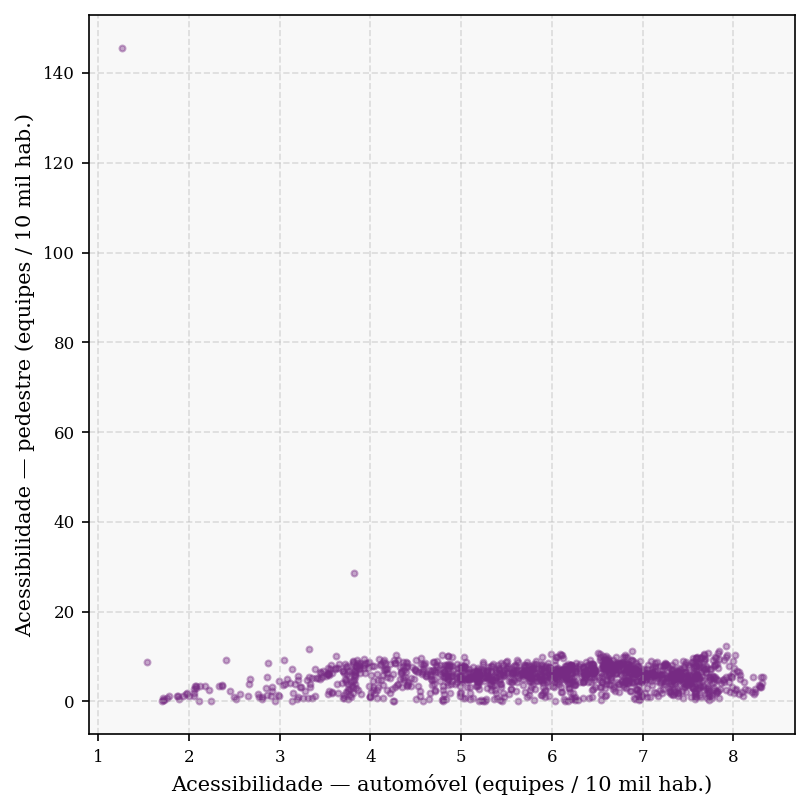

In [12]:
# ── 7. COMPARAÇÃO ENTRE MODOS ───────────────────────────────────────────────
comp = ac[(ac["acess_carro"] > 0) & (ac["acess_pe"] > 0)]
rho_modos, _ = spearmanr(comp["acess_carro"], comp["acess_pe"])
print(f"Spearman acesso carro × pé = {rho_modos:.3f}  (≈0 ⇒ padrões quase independentes)")
print(f"Acesso × renda: carro = {rho_h1:+.3f} | pé = {rho_pe:+.3f}  (inversão de sinal)")

fig, ax = plt.subplots(figsize=(5.5, 5.5))
ax.scatter(comp["acess_carro"] * 1e4, comp["acess_pe"] * 1e4, s=8, alpha=0.4, color="#762A83")
ax.set_xlabel("Acessibilidade — automóvel (equipes / 10 mil hab.)")
ax.set_ylabel("Acessibilidade — pedestre (equipes / 10 mil hab.)")
plt.tight_layout()
fig.savefig(FIGURAS_NB / "nb061_fig05_comparacao_modos.png", dpi=300, bbox_inches="tight")
plt.show()

                      n spearman  p_valor pearson
todos os setores   1357    0.069  1.1e-02   0.002
sem os 2 atípicos  1355    0.073  7.3e-03   0.148
Acesso × renda: carro = +0.438 | pé = -0.199  (inversão de sinal)


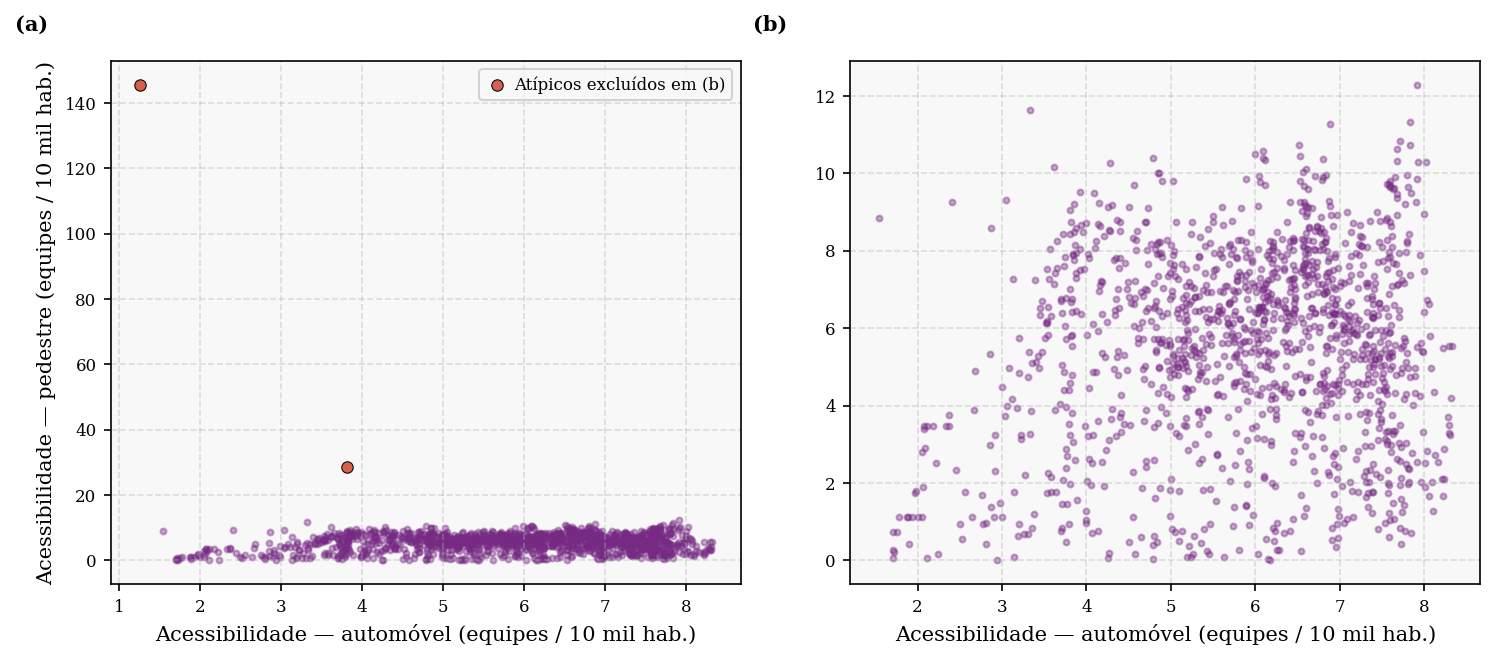

In [13]:
# ── 7. COMPARAÇÃO ENTRE MODOS + verificação de robustez (sem atípicos) ──────
# Setores com índice a pé atípico (recomendação da orientação): o 1º é
# artefato de denominador pequeno (145,6 eq./10 mil hab.; p99 = 10,4).
ATIPICOS_PE = ["221100105090225", "221100105100264"]

comp = ac[(ac["acess_carro"] > 0) & (ac["acess_pe"] > 0)]
comp_sem = comp[~comp["CD_SETOR"].isin(ATIPICOS_PE)]
assert len(comp) - len(comp_sem) == len(ATIPICOS_PE), "algum CD_SETOR atípico não foi encontrado"

def correlacoes(df):
    rho, p = spearmanr(df["acess_carro"], df["acess_pe"])
    r,  _  = pearsonr(df["acess_carro"], df["acess_pe"])
    return {"n": len(df), "spearman": round(rho, 3), "p_valor": f"{p:.1e}", "pearson": round(r, 3)}

rob = pd.DataFrame({"todos os setores": correlacoes(comp),
                    "sem os 2 atípicos": correlacoes(comp_sem)}).T
print(rob.to_string())
rob.to_csv(TABELAS_NB / "nb061_comparacao_modos_robustez.csv", sep=";", encoding="utf-8-sig")

rho_modos = rob.loc["todos os setores", "spearman"]     # mantém a variável usada adiante
print(f"Acesso × renda: carro = {rho_h1:+.3f} | pé = {rho_pe:+.3f}  (inversão de sinal)")

# Figura: (a) todos, atípicos destacados; (b) sem os atípicos (escala legível)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4.5))
atip = comp[comp["CD_SETOR"].isin(ATIPICOS_PE)]
ax1.scatter(comp_sem["acess_carro"] * 1e4, comp_sem["acess_pe"] * 1e4, s=8, alpha=0.4, color="#762A83")
ax1.scatter(atip["acess_carro"] * 1e4, atip["acess_pe"] * 1e4, s=30, color="#D6604D",
            edgecolor="black", linewidth=0.5, label="Atípicos excluídos em (b)")
ax1.legend(fontsize=8)
ax2.scatter(comp_sem["acess_carro"] * 1e4, comp_sem["acess_pe"] * 1e4, s=8, alpha=0.4, color="#762A83")
for ax in (ax1, ax2):
    ax.set_xlabel("Acessibilidade — automóvel (equipes / 10 mil hab.)")
ax1.set_ylabel("Acessibilidade — pedestre (equipes / 10 mil hab.)")
ax1.text(-0.1, 1.05, "(a)", transform=ax1.transAxes, fontsize=10, fontweight="bold", va="bottom", ha="right")
ax2.text(-0.1, 1.05, "(b)", transform=ax2.transAxes, fontsize=10, fontweight="bold", va="bottom", ha="right")
plt.tight_layout()
fig.savefig(FIGURAS_NB / "nb061_fig05_comparacao_modos_sem_outlier.png", dpi=300, bbox_inches="tight")
plt.show()

## Síntese dos testes
- **H2**: o diagnóstico areal concorda fortemente com o tradicional (ρ = 0,991 no automóvel;
  0,949 a pé). No automóvel, a correção areal é marginal (23 setores reclassificados); a pé,
  é substancial (78 reclassificados, dos quais 64 são falsos desertos do centroide).
- **H1**: no automóvel, a acessibilidade associa-se **positivamente** à renda (ρ = +0,44;
  Moran I = 0,93), com agrupamentos *baixo acesso–baixa renda* na periferia. A pé, a
  associação **inverte** (ρ = −0,20) e predominam agrupamentos *alto acesso–baixa renda*.
- **Modos**: os índices de automóvel e pedestre são quase independentes (ρ = 0,07): a
  iniquidade territorial depende do modo de deslocamento considerado.